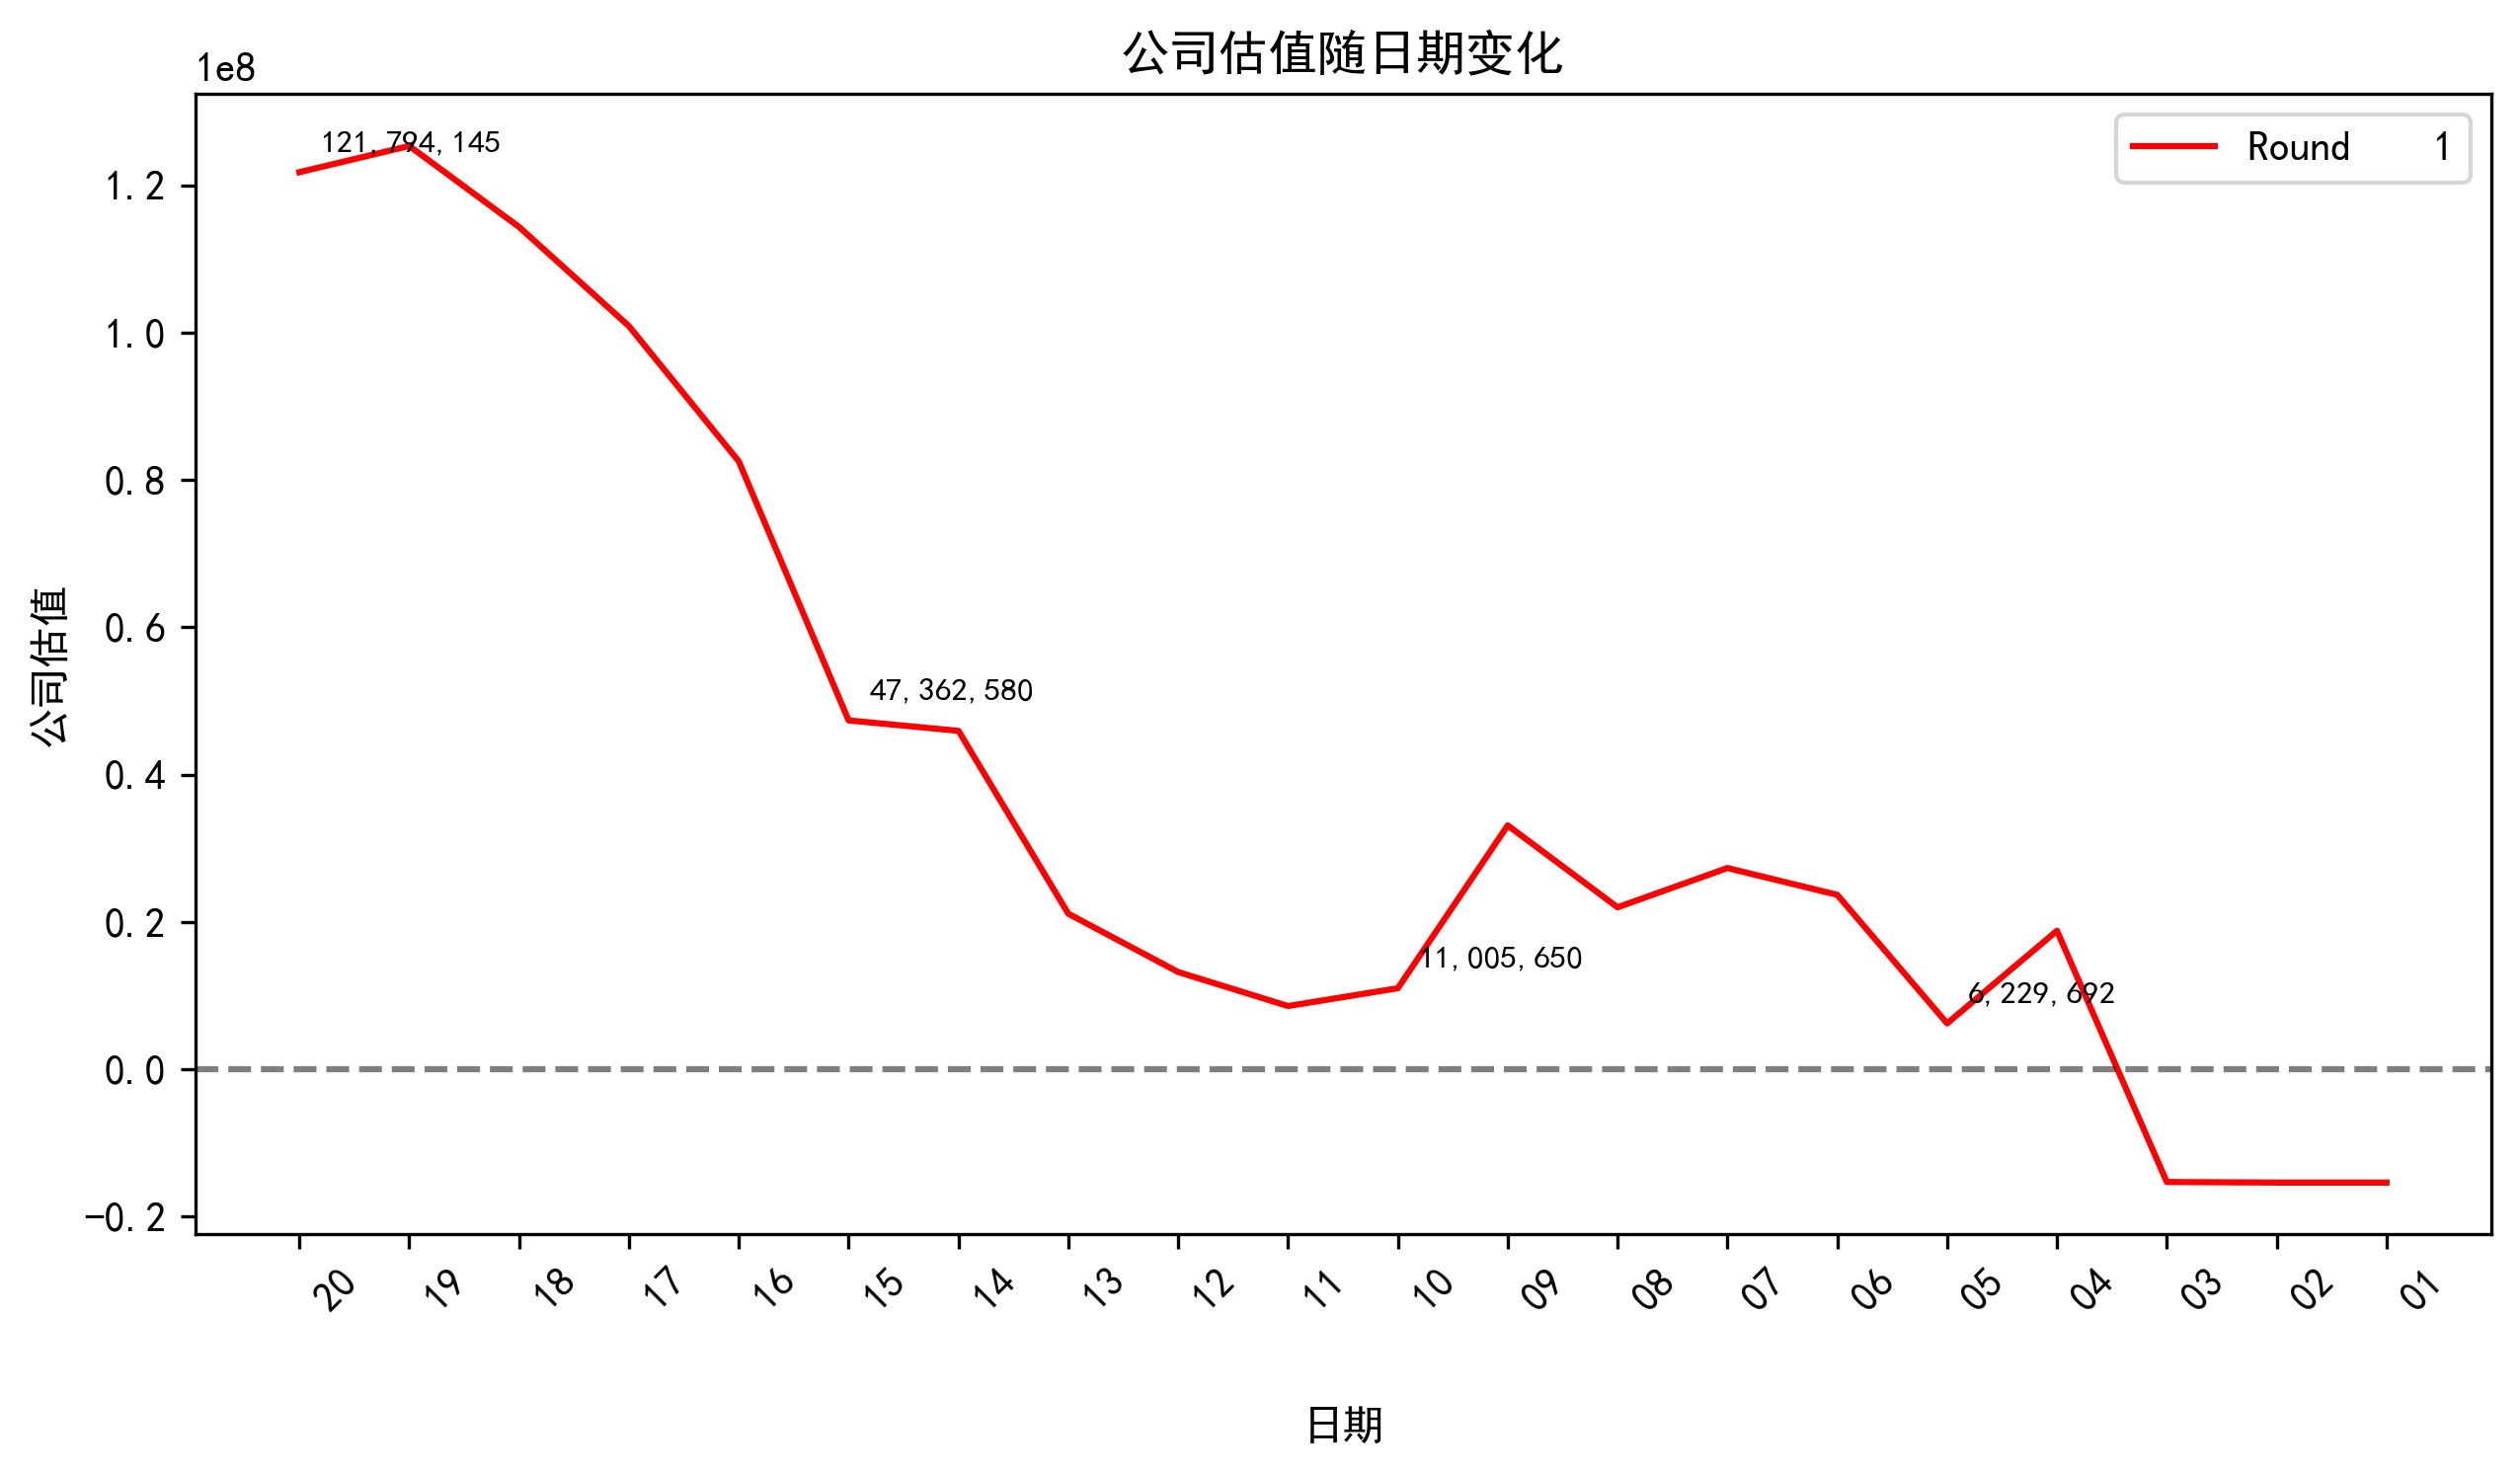

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 读取 Excel 文件
excel_file = pd.ExcelFile('公司估值.xlsx')

# 获取指定工作表中的数据
df = excel_file.parse('Sheet1')

rows, columns = df.shape

# 提取第 7 行(index=6)至第 86 行(index=85)中`Unnamed: 1`列、`Unnamed: 2`列和`Unnamed: 3`列的数据
data = df.loc[6:rows, ['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']]

# 设置列名
data.columns = ['Round', 'Day', 'Company Valuation']

# 转换数据类型
data['Company Valuation'] = data['Company Valuation'].str.replace(',', '').astype(float)

# 设置图片清晰度
plt.rcParams['figure.dpi'] = 300

# 设置中文字体为黑体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 设置画布大小
plt.figure(figsize=(10, 5))

# 定义颜色列表
colors = ['r', 'g', 'b', 'y']

# 遍历不同的轮次
for i, round_num in enumerate(data['Round'].unique()):
    round_data = data[data['Round'] == round_num]
    plt.plot(round_data['Day'], round_data['Company Valuation'], label=f'Round {round_num}', color=colors[i % len(colors)])

    # 每 5 天在线上标注数据
    for j in range(0, len(round_data), 5):
        plt.annotate(f'{round_data["Company Valuation"].iloc[j]:,.0f}',
                     xy=(round_data['Day'].iloc[j], round_data['Company Valuation'].iloc[j]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

# 找出由负转正的位置并画横虚线
crossing_points = np.where(np.diff(np.sign(data['Company Valuation'])))[0] + 1
for point in crossing_points:
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

# 设置图表标题和坐标轴标签
plt.title('公司估值随日期变化')
plt.xlabel('日期')
plt.xticks(rotation=45)
plt.ylabel('公司估值')

# 显示图例
plt.legend()

# 保存图片
plt.savefig(f'公司估值随日期变化.png',
            bbox_inches='tight',
            dpi=300)

# 显示图表
plt.show()